# Regressão Linear - AGRO3 (Dataset Indicadores Técnicos)
## Análise comparativa de modelos de Machine Learning - Agro Brasil - TCC

Este notebook implementa modelos de regressão linear para prever o preço de fechamento futuro das ações AGRO3 em diferentes horizontes temporais (3, 7, 15 e 30 dias).

**Dataset utilizado:** Dataset com indicadores técnicos (OBV, FWMA, TEMA, HLC3, Bollinger Bands).

### Importação das bibliotecas e carregamento do dataset

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from scipy import stats
import os

# Configuração para salvar gráficos
OUTPUT_DIR = './'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Carrega o dataset tratado com indicadores técnicos
df = pd.read_csv('../../../../datasets/datasets_indicadores/regressao/AGRO3_tratado.csv', index_col=0, parse_dates=True)

print("="*60)
print("DATASET AGRO3 - REGRESSÃO LINEAR (INDICADORES TÉCNICOS)")
print("="*60)
print(f"\nPrimeiras 5 linhas do DataFrame:")
print(df.head())

print(f"\nInformações gerais do DataFrame:")
print(df.info())

print(f"\nColunas disponíveis:")
print(df.columns.tolist())

print(f"\nEstatísticas descritivas:")
print(df.describe())

DATASET AGRO3 - REGRESSÃO LINEAR (INDICADORES TÉCNICOS)

Primeiras 5 linhas do DataFrame:
               Close      High       Low      Open  Volume  Close_3d_fut  \
Date                                                                       
2018-01-29  7.465568  7.510439  7.409477  7.510439   12100      7.560920   
2018-01-30  7.454350  7.493612  7.358997  7.493612   29000      7.566530   
2018-01-31  7.516049  7.516049  7.375824  7.431914   59500      7.459959   
2018-02-01  7.560920  7.740408  7.454349  7.504830   72900      7.398259   
2018-02-02  7.566530  7.628229  7.381434  7.560921   60600      7.572138   

            Close_7d_fut  Close_15d_fut  Close_30d_fut     OBV      FWMA  \
Date                                                                       
2018-01-29      7.572138       7.656273       7.454350   52300  7.469487   
2018-01-30      7.572138       7.740409       7.403867   23300  7.463770   
2018-01-31      7.544093       7.706754       7.375823   82800  7.483749 

### Preparação dos dados para modelagem

In [2]:
# Identificar colunas de indicadores técnicos
indicadores_cols = ['OBV', 'FWMA', 'TEMA', 'HLC3', 'BB_upper', 'BB_middle', 'BB_lower']
indicadores_presentes = [col for col in indicadores_cols if col in df.columns]
print(f"Indicadores técnicos encontrados ({len(indicadores_presentes)}): {indicadores_presentes}")

# Definir variáveis independentes (features base + indicadores)
base_features = ['Close', 'Low', 'High', 'Open']
X = df[base_features + indicadores_presentes]

# Definir targets (variáveis dependentes) - janelas temporais
targets = {
    '3d': df['Close_3d_fut'],
    '7d': df['Close_7d_fut'], 
    '15d': df['Close_15d_fut'],
    '30d': df['Close_30d_fut']
}

print("\nVariáveis independentes (X):")
print(X.columns.tolist())
print(f"\nShape de X: {X.shape}")

print("\nTargets (janelas temporais):")
for name, target in targets.items():
    print(f"  - {name}: {target.name}")

Indicadores técnicos encontrados (7): ['OBV', 'FWMA', 'TEMA', 'HLC3', 'BB_upper', 'BB_middle', 'BB_lower']

Variáveis independentes (X):
['Close', 'Low', 'High', 'Open', 'OBV', 'FWMA', 'TEMA', 'HLC3', 'BB_upper', 'BB_middle', 'BB_lower']

Shape de X: (1689, 11)

Targets (janelas temporais):
  - 3d: Close_3d_fut
  - 7d: Close_7d_fut
  - 15d: Close_15d_fut
  - 30d: Close_30d_fut


### Treinamento dos Modelos de Regressão Linear

In [3]:
print("MODELOS DE REGRESSÃO LINEAR - AGRO3 (INDICADORES TÉCNICOS)")
print("="*60)

# Dicionário para armazenar modelos treinados e métricas
models = {}

# Treinar modelo para cada janela temporal
for period, y in targets.items():
    # Divisão treino-teste (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)
    
    # Treinar modelo
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Fazer predições
    y_pred = model.predict(X_test)
    
    # Calcular métricas
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    
    # Armazenar modelo e métricas
    models[period] = {
        'model': model,
        'r2': r2,
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_pred': y_pred
    }
    
    print(f"\nMODELO {period.upper()} - Predição Close {period} futuro:")
    print(f"  R²: {r2:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  Intercepto: {model.intercept_:.4f}")
    print(f"  Coeficientes:")
    for i, feature in enumerate(X.columns):
        print(f"    {feature}: {model.coef_[i]:.4f}")

print(f"\n" + "="*60)
print(f"✓ 4 modelos treinados com sucesso!")
print("="*60)

MODELOS DE REGRESSÃO LINEAR - AGRO3 (INDICADORES TÉCNICOS)

MODELO 3D - Predição Close 3d futuro:
  R²: 0.9896
  MAE: 0.4077
  RMSE: 0.6075
  Intercepto: 0.0303
  Coeficientes:
    Close: 0.8136
    Low: 0.1106
    High: 0.3693
    Open: -0.2215
    OBV: -0.0000
    FWMA: -1.8055
    TEMA: 0.9891
    HLC3: 0.4312
    BB_upper: 0.0949
    BB_middle: 0.1042
    BB_lower: 0.1136

MODELO 7D - Predição Close 7d futuro:
  R²: 0.9772
  MAE: 0.6087
  RMSE: 0.8929
  Intercepto: 0.0516
  Coeficientes:
    Close: 1.2292
    Low: -0.0087
    High: 0.2582
    Open: 0.1616
    OBV: -0.0000
    FWMA: -3.8157
    TEMA: 2.0628
    HLC3: 0.4929
    BB_upper: 0.1790
    BB_middle: 0.2087
    BB_lower: 0.2385

MODELO 15D - Predição Close 15d futuro:
  R²: 0.9520
  MAE: 0.9214
  RMSE: 1.3024
  Intercepto: 0.0183
  Coeficientes:
    Close: 1.5303
    Low: -0.2078
    High: 0.3253
    Open: 0.4182
    OBV: -0.0000
    FWMA: -5.5310
    TEMA: 3.0030
    HLC3: 0.5493
    BB_upper: 0.2216
    BB_middle: 0.3123


### Tabela Resumo das Métricas

In [4]:
# Criar DataFrame com resumo das métricas
metrics_summary = pd.DataFrame({
    'Horizonte': ['3 dias', '7 dias', '15 dias', '30 dias'],
    'R²': [models['3d']['r2'], models['7d']['r2'], models['15d']['r2'], models['30d']['r2']],
    'MAE': [models['3d']['mae'], models['7d']['mae'], models['15d']['mae'], models['30d']['mae']],
    'RMSE': [models['3d']['rmse'], models['7d']['rmse'], models['15d']['rmse'], models['30d']['rmse']]
})

print("\nRESUMO DAS MÉTRICAS - AGRO3 (INDICADORES TÉCNICOS)")
print("="*60)
print(metrics_summary.to_string(index=False))

# Salvar métricas em CSV
metrics_summary.to_csv(f'{OUTPUT_DIR}metricas_agro3_indicadores.csv', index=False)
print(f"\n✓ Métricas salvas em metricas_agro3_indicadores.csv")


RESUMO DAS MÉTRICAS - AGRO3 (INDICADORES TÉCNICOS)
Horizonte       R²      MAE     RMSE
   3 dias 0.989643 0.407682 0.607467
   7 dias 0.977246 0.608671 0.892923
  15 dias 0.952016 0.921447 1.302405
  30 dias 0.907608 1.310268 1.792104

✓ Métricas salvas em metricas_agro3_indicadores.csv


---
# Análises Gráficas

### Gráficos de Série Temporal - Real vs Predito

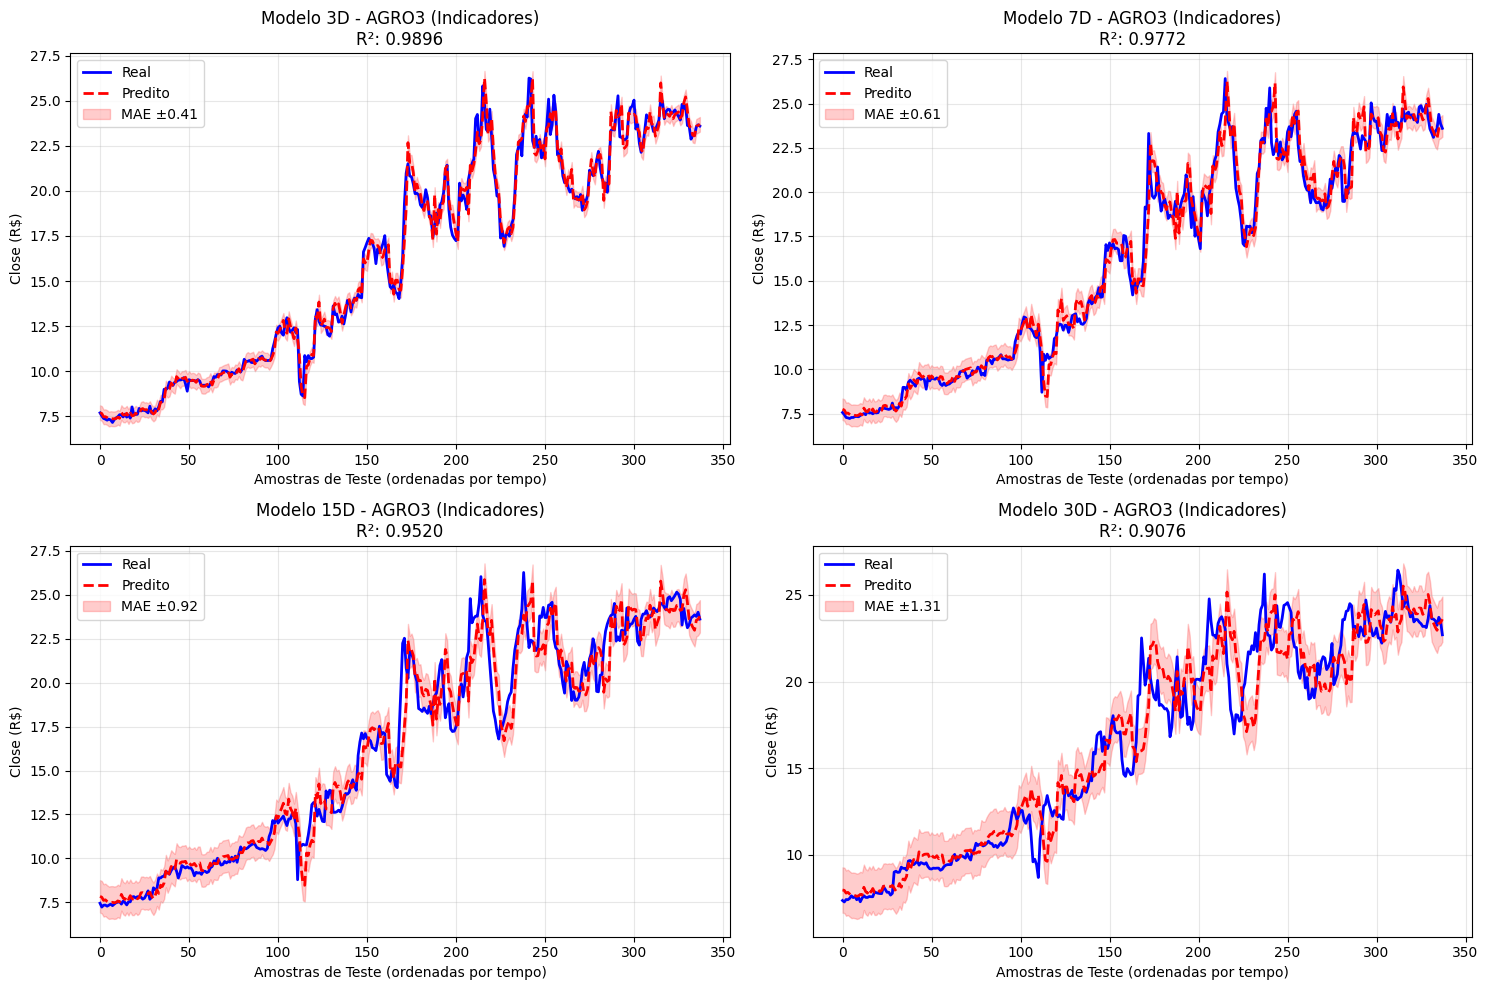

✓ Gráfico de série temporal salvo


In [5]:
# Gráficos de série temporal
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    mae = model_data['mae']
    
    # Ordenar por índice para visualização temporal
    test_indices = model_data['X_test'].index
    sorted_indices = sorted(range(len(test_indices)), key=lambda i: test_indices[i])
    
    y_test_sorted = y_test.iloc[sorted_indices]
    y_pred_sorted = y_pred[sorted_indices]
    
    # Plotar
    ax = axes[idx]
    ax.plot(range(len(y_test_sorted)), y_test_sorted, 'b-', label='Real', linewidth=2)
    ax.plot(range(len(y_pred_sorted)), y_pred_sorted, 'r--', label='Predito', linewidth=2)
    
    # Adicionar túnel do MAE
    ax.fill_between(range(len(y_pred_sorted)), 
                    y_pred_sorted - mae, 
                    y_pred_sorted + mae, 
                    alpha=0.2, color='red', label=f'MAE ±{mae:.2f}')
    
    ax.set_title(f'Modelo {period.upper()} - AGRO3 (Indicadores)\nR²: {model_data["r2"]:.4f}')
    ax.set_xlabel('Amostras de Teste (ordenadas por tempo)')
    ax.set_ylabel('Close (R$)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}serie_temporal_agro3_indicadores.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico de série temporal salvo")

### Gráficos de Resíduos

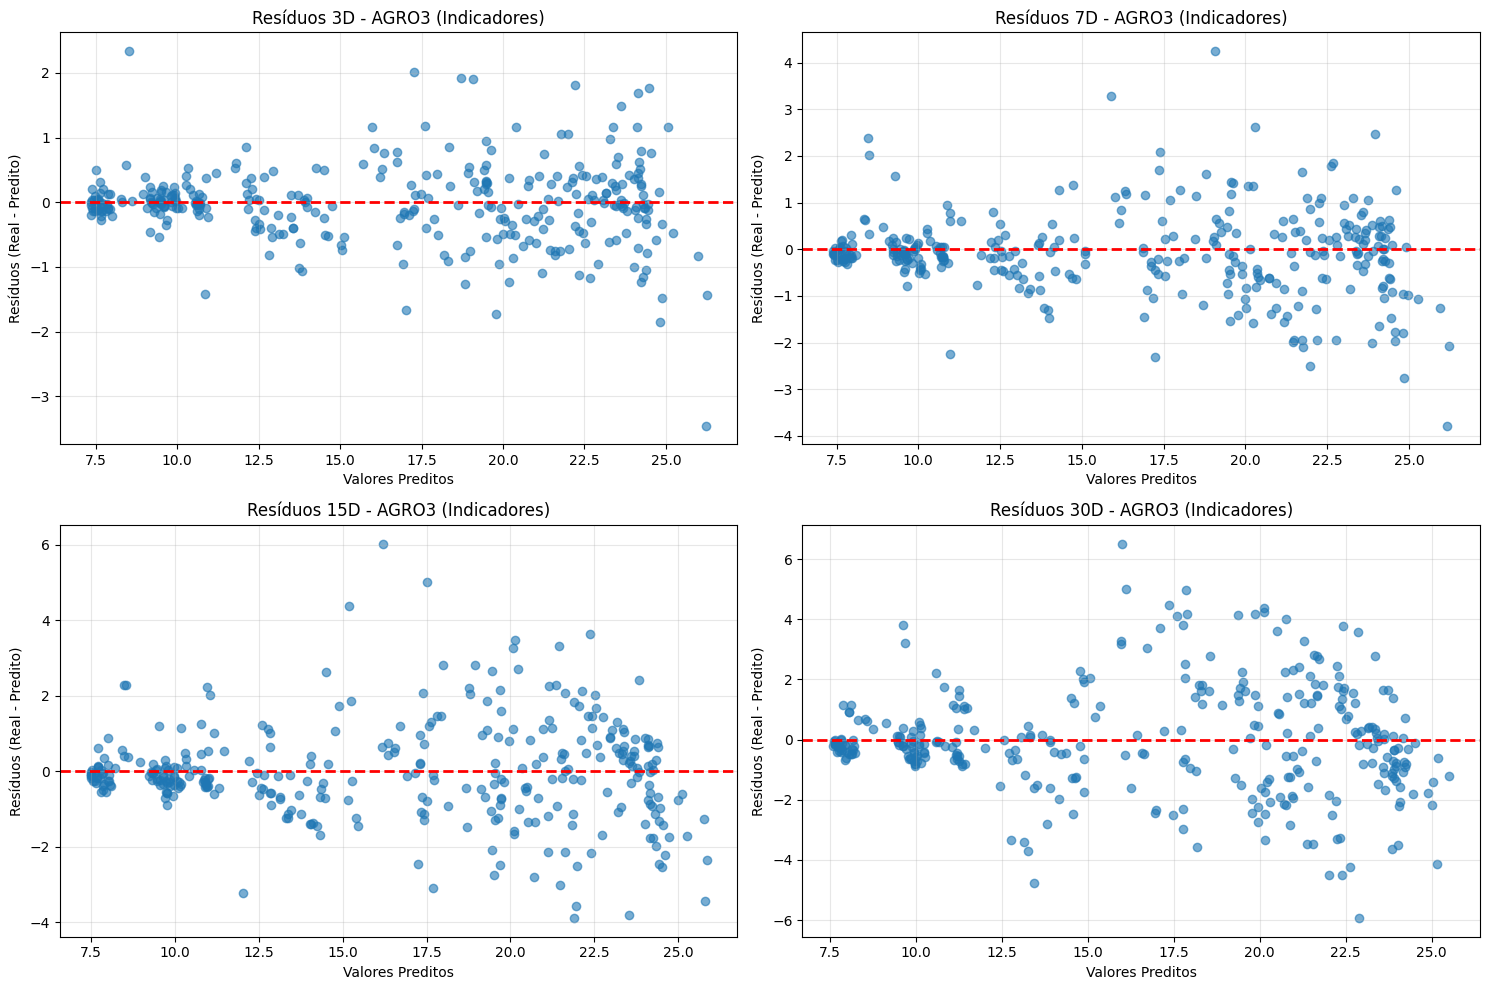

✓ Gráfico de resíduos salvo


In [6]:
# Gráficos de resíduos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    residuos = y_test - y_pred
    
    # Plotar
    ax = axes[idx]
    ax.scatter(y_pred, residuos, alpha=0.6)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'Resíduos {period.upper()} - AGRO3 (Indicadores)')
    ax.set_xlabel('Valores Preditos')
    ax.set_ylabel('Resíduos (Real - Predito)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}residuos_agro3_indicadores.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico de resíduos salvo")

### Gráficos Real vs Predito

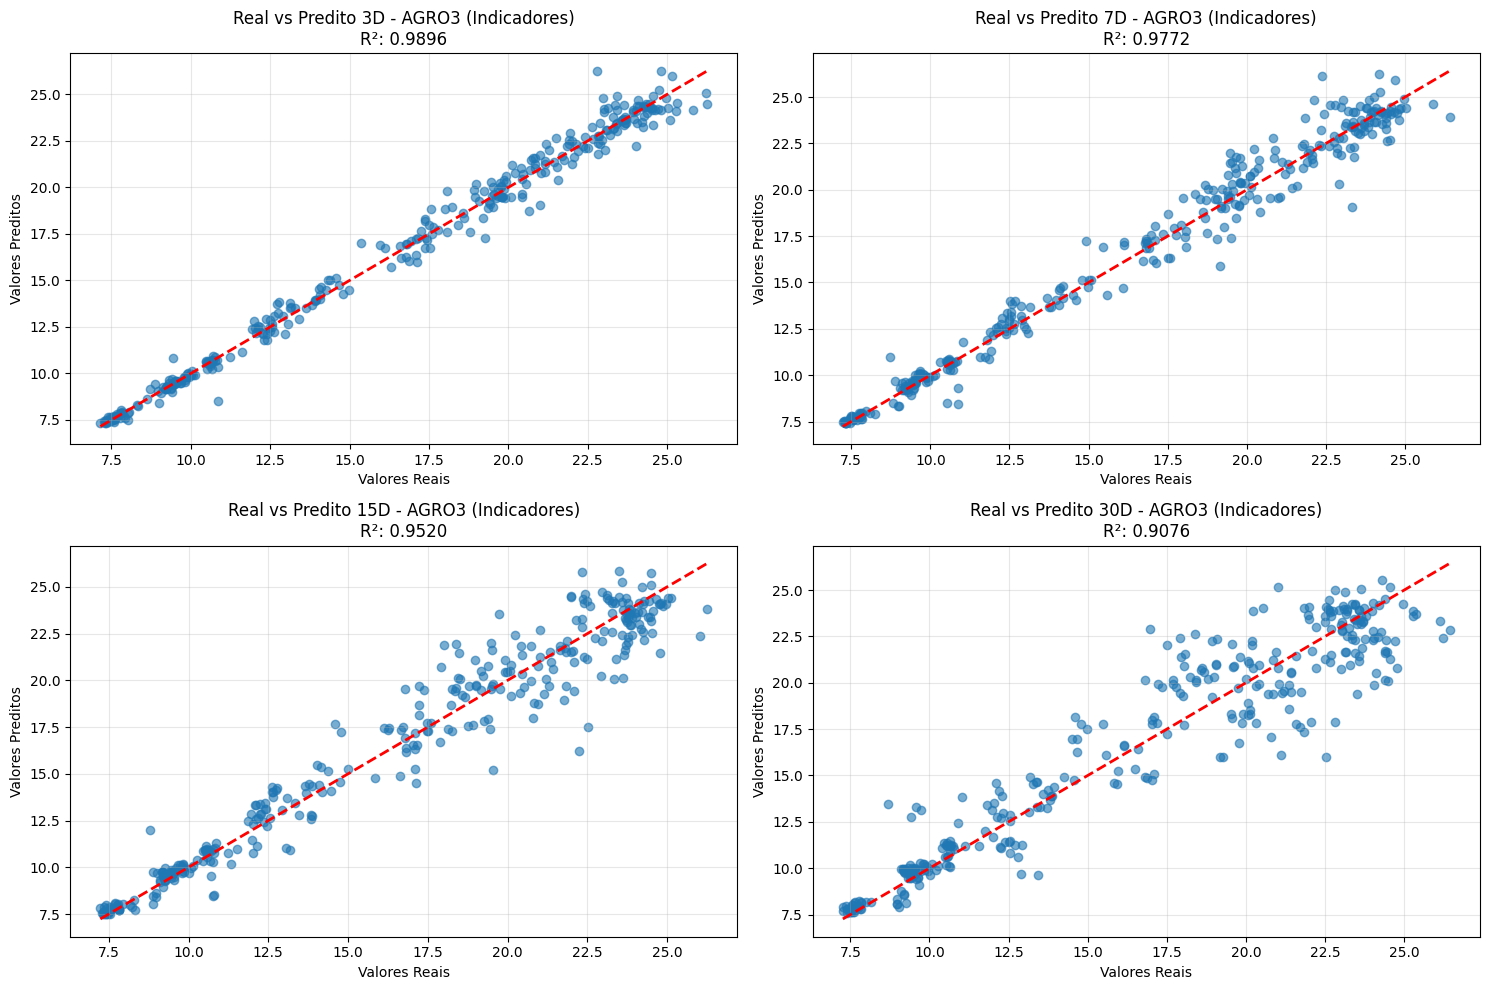

✓ Gráfico real vs predito salvo


In [7]:
# Gráficos Real vs Predito
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    
    # Plotar
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.6)
    
    # Linha diagonal y=x (predição perfeita)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    
    ax.set_title(f'Real vs Predito {period.upper()} - AGRO3 (Indicadores)\nR²: {model_data["r2"]:.4f}')
    ax.set_xlabel('Valores Reais')
    ax.set_ylabel('Valores Preditos')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}real_vs_predito_agro3_indicadores.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico real vs predito salvo")

### Comparação das Métricas (R² e MAE)

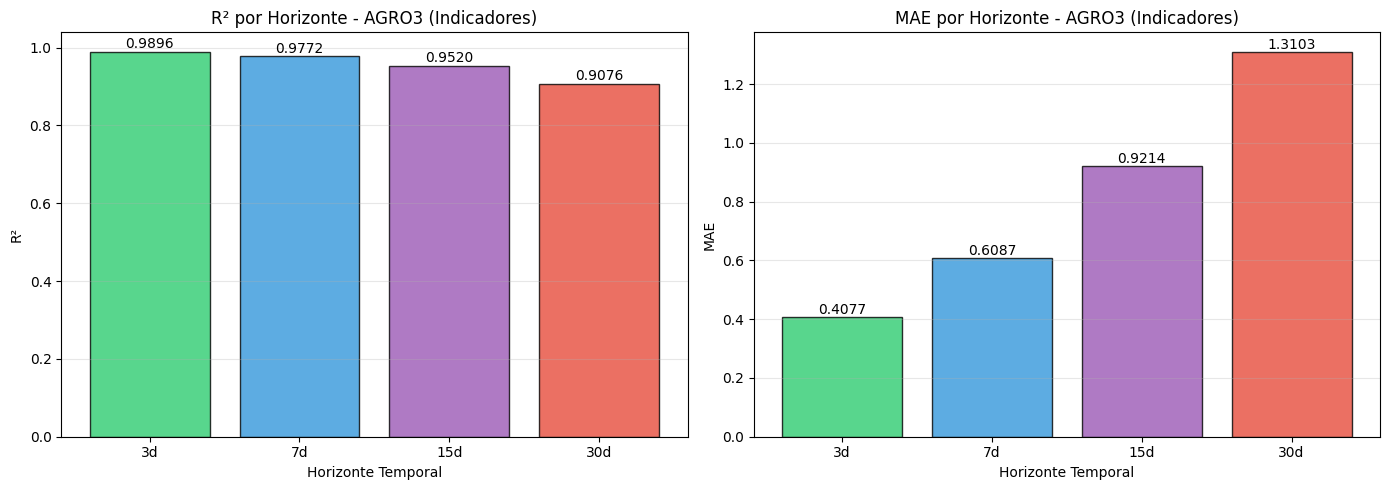

✓ Gráfico de comparação de métricas salvo


In [8]:
# Comparação das métricas entre horizontes
periods = ['3d', '7d', '15d', '30d']
r2_values = [models[p]['r2'] for p in periods]
mae_values = [models[p]['mae'] for p in periods]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico R²
x = np.arange(len(periods))
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

ax1.bar(x, r2_values, color=colors, alpha=0.8, edgecolor='black')
ax1.set_xlabel('Horizonte Temporal')
ax1.set_ylabel('R²')
ax1.set_title('R² por Horizonte - AGRO3 (Indicadores)')
ax1.set_xticks(x)
ax1.set_xticklabels(periods)
ax1.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for i, v in enumerate(r2_values):
    ax1.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

# Gráfico MAE
ax2.bar(x, mae_values, color=colors, alpha=0.8, edgecolor='black')
ax2.set_xlabel('Horizonte Temporal')
ax2.set_ylabel('MAE')
ax2.set_title('MAE por Horizonte - AGRO3 (Indicadores)')
ax2.set_xticks(x)
ax2.set_xticklabels(periods)
ax2.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for i, v in enumerate(mae_values):
    ax2.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}comparacao_metricas_agro3_indicadores.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico de comparação de métricas salvo")

### Histogramas dos Resíduos

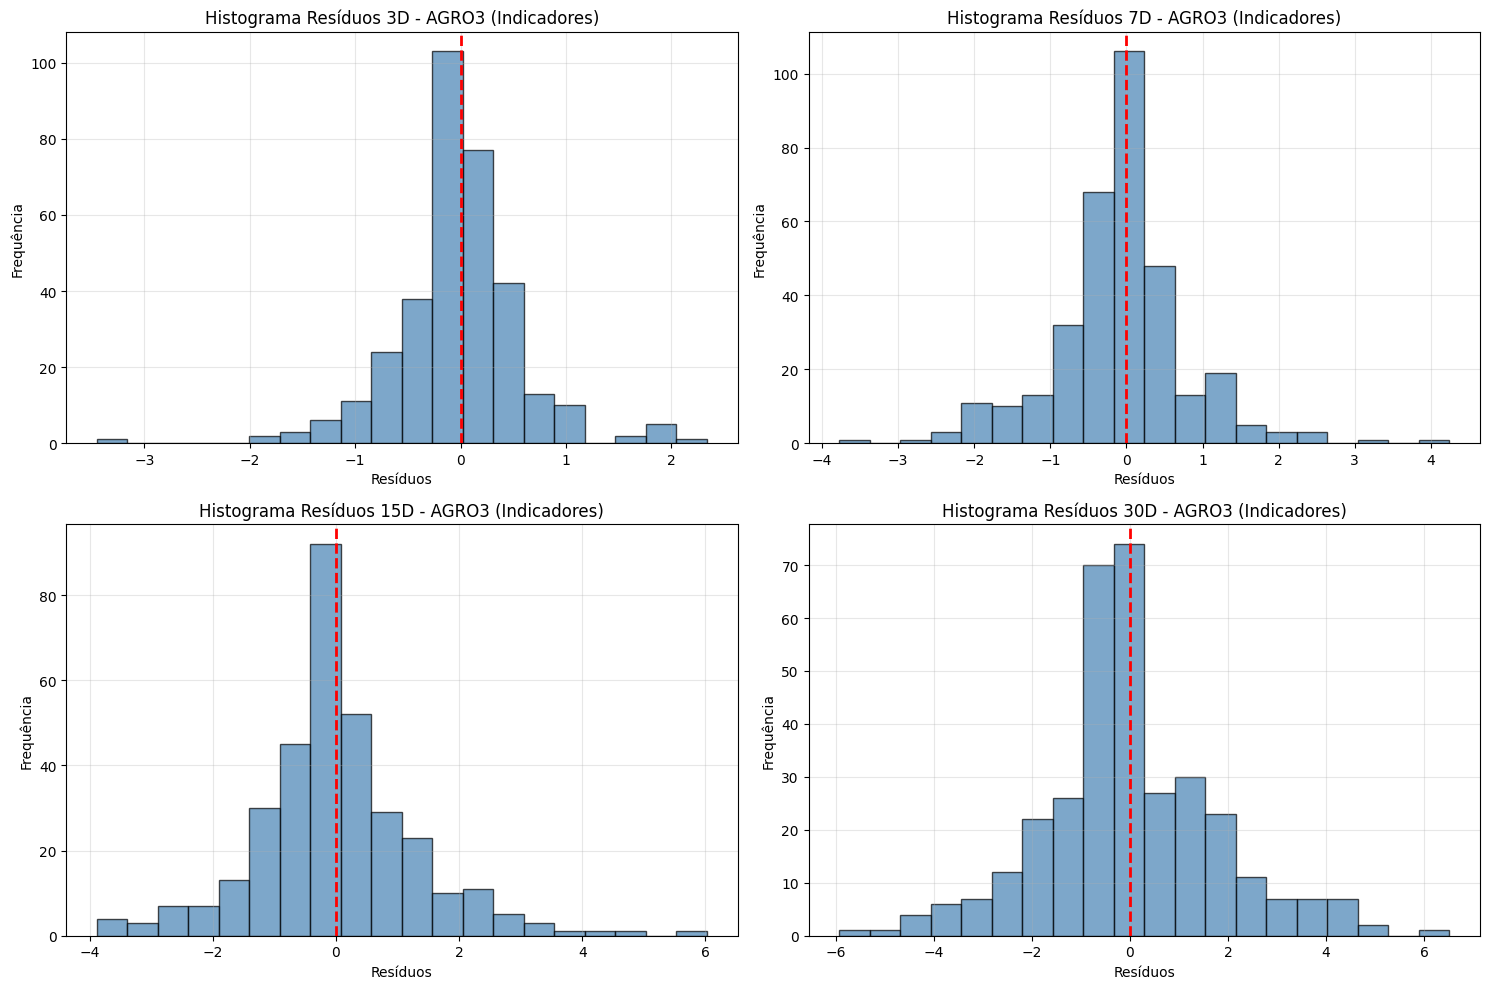

✓ Histograma de resíduos salvo


In [9]:
# Histogramas dos resíduos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    residuos = y_test - y_pred
    
    # Plotar
    ax = axes[idx]
    ax.hist(residuos, bins=20, alpha=0.7, edgecolor='black', color='steelblue')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'Histograma Resíduos {period.upper()} - AGRO3 (Indicadores)')
    ax.set_xlabel('Resíduos')
    ax.set_ylabel('Frequência')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}histograma_residuos_agro3_indicadores.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Histograma de resíduos salvo")

### Resíduos vs Ordem Temporal

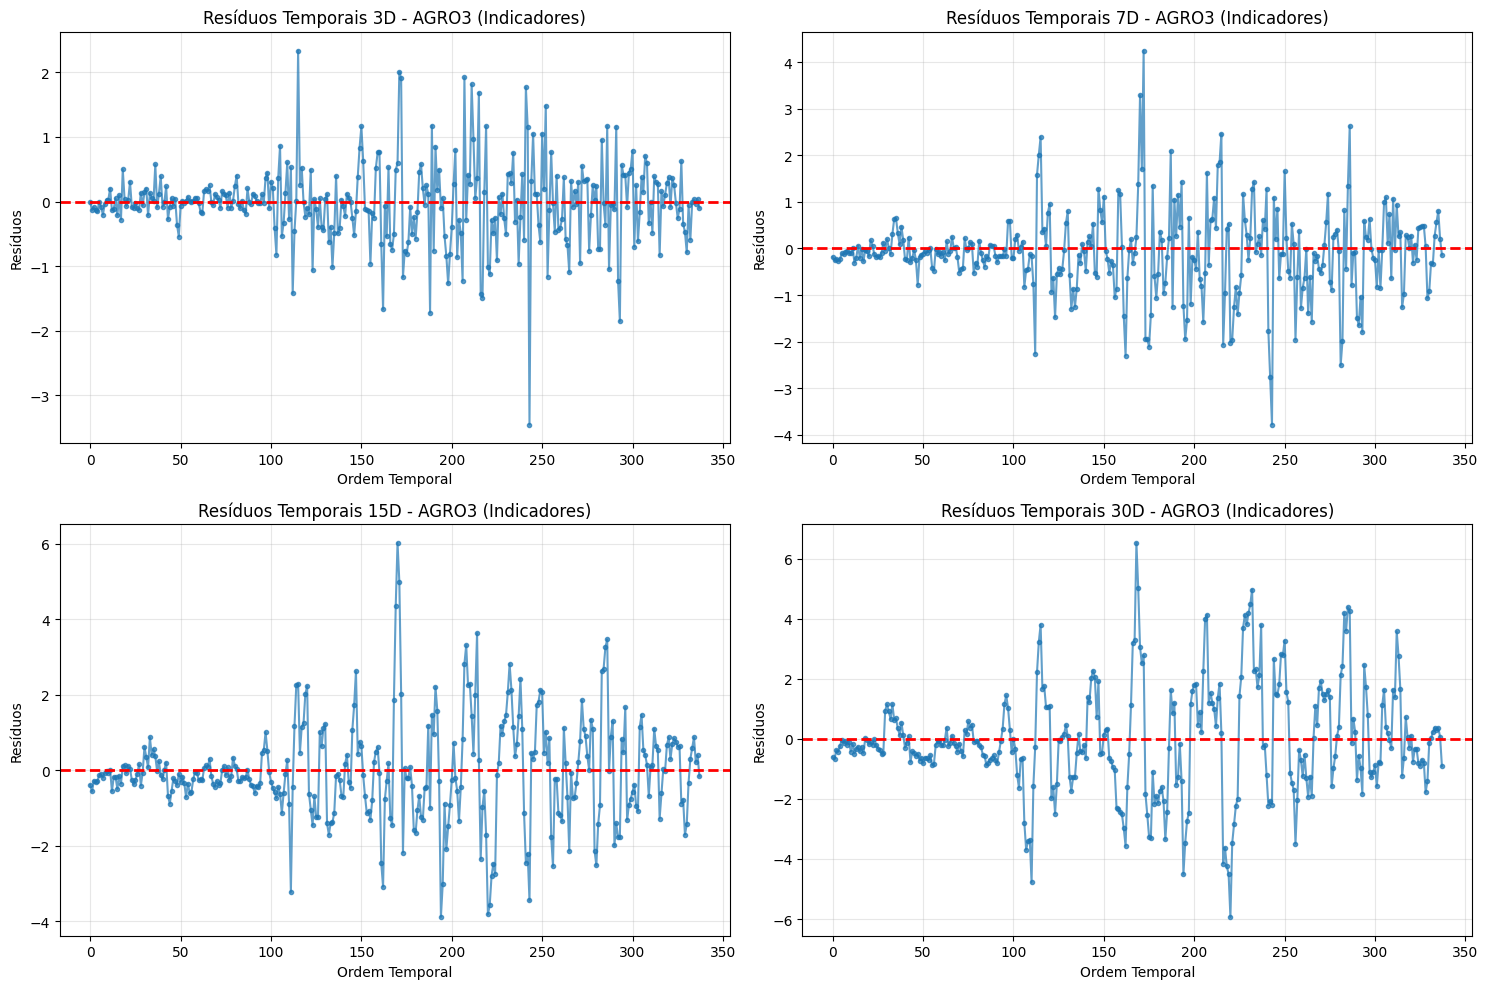

✓ Gráfico de resíduos temporais salvo


In [10]:
# Resíduos vs Ordem Temporal
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    residuos = y_test - y_pred
    
    # Ordenar por índice temporal
    test_indices = model_data['X_test'].index
    sorted_indices = sorted(range(len(test_indices)), key=lambda i: test_indices[i])
    residuos_sorted = residuos.iloc[sorted_indices]
    
    # Plotar
    ax = axes[idx]
    ax.plot(range(len(residuos_sorted)), residuos_sorted, 'o-', markersize=3, alpha=0.7)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'Resíduos Temporais {period.upper()} - AGRO3 (Indicadores)')
    ax.set_xlabel('Ordem Temporal')
    ax.set_ylabel('Resíduos')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}residuos_temporais_agro3_indicadores.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico de resíduos temporais salvo")

### Gráfico de Dispersão com Intervalo de Confiança (IC 95%)

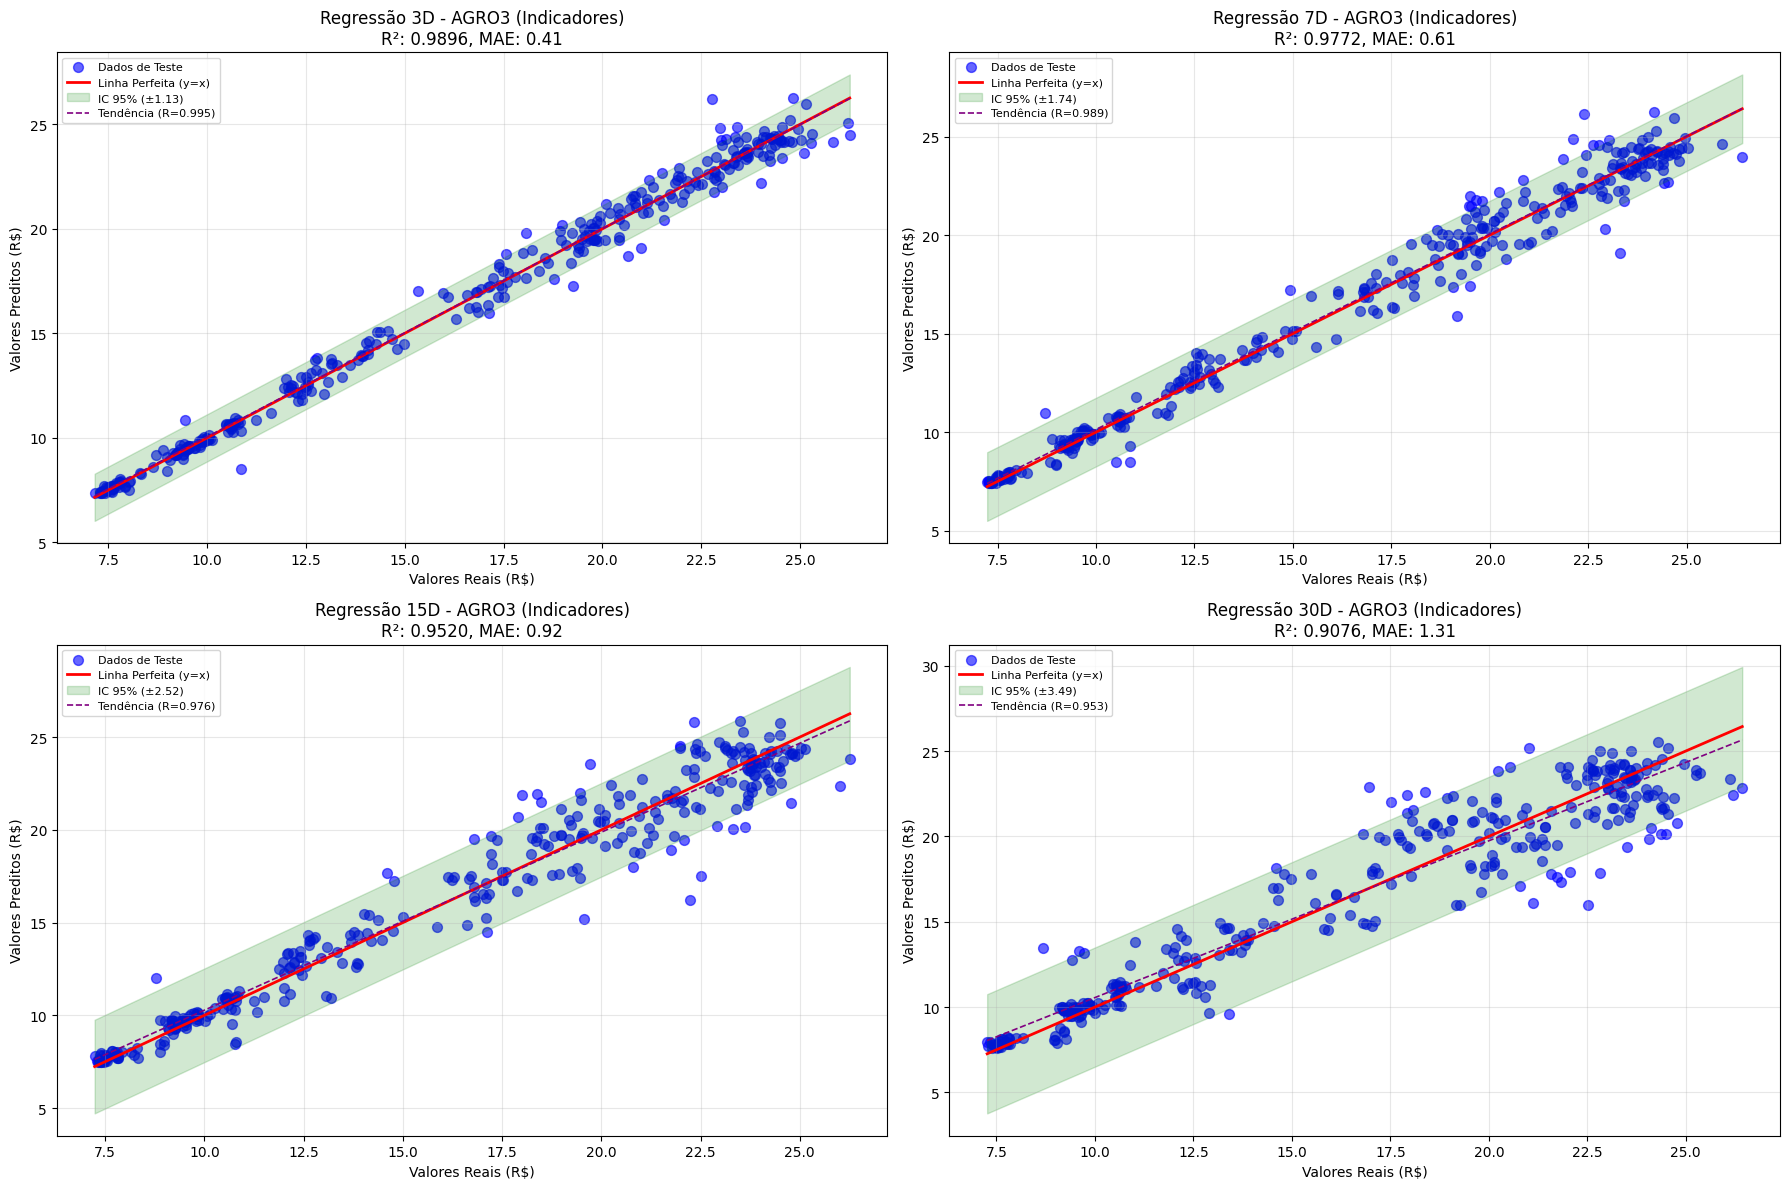

✓ Gráfico de dispersão com IC 95% salvo


In [11]:
# Gráficos de dispersão com linha de regressão e IC 95%
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    y_train = model_data['y_train']
    y_pred_train = model_data['model'].predict(model_data['X_train'])
    
    # Calcular MSE e desvio padrão dos resíduos
    mse = mean_squared_error(y_train, y_pred_train)
    residual_std = np.sqrt(mse)

    ax = axes[idx]

    # Scatter dos dados de teste
    ax.scatter(y_test, y_pred, alpha=0.6, color='blue', s=50, label='Dados de Teste')

    # Linha y = x
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    line_vals = np.linspace(min_val, max_val, 100)
    ax.plot(line_vals, line_vals, 'r-', linewidth=2, label='Linha Perfeita (y=x)')

    # Intervalo de confiança 95%
    confidence_interval = 1.96 * residual_std
    ax.fill_between(line_vals,
                    line_vals - confidence_interval,
                    line_vals + confidence_interval,
                    alpha=0.18, color='green',
                    label=f'IC 95% (±{confidence_interval:.2f})')

    # Linha de tendência
    slope, intercept, r_value, p_value, std_err = stats.linregress(y_test, y_pred)
    regression_line = slope * line_vals + intercept
    ax.plot(line_vals, regression_line, '--', color='purple', linewidth=1.2, label=f'Tendência (R={r_value:.3f})')

    ax.set_title(f'Regressão {period.upper()} - AGRO3 (Indicadores)\nR²: {model_data["r2"]:.4f}, MAE: {model_data["mae"]:.2f}')
    ax.set_xlabel('Valores Reais (R$)')
    ax.set_ylabel('Valores Preditos (R$)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}dispersao_ic_agro3_indicadores.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico de dispersão com IC 95% salvo")

### Evolução do R² e MAE por Horizonte

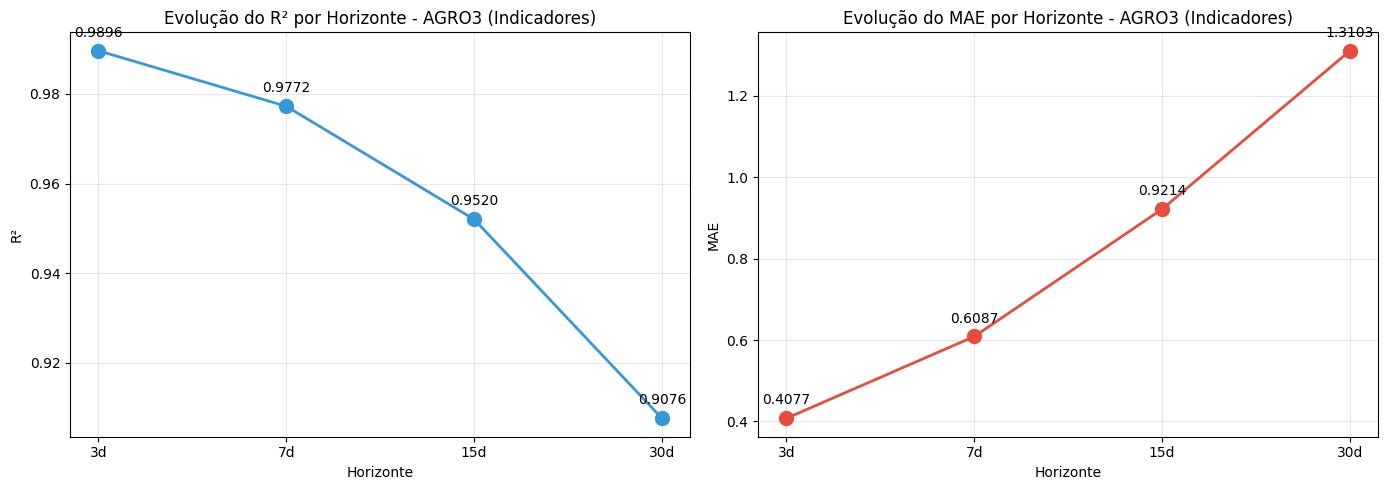

✓ Gráficos de evolução de R² e MAE salvos


In [12]:
# Evolução das métricas R² e MAE por horizonte
periods = ['3d', '7d', '15d', '30d']
r2_values = [models[p]['r2'] for p in periods]
mae_values = [models[p]['mae'] for p in periods]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot R²
axes[0].plot(periods, r2_values, marker='o', linewidth=2, markersize=10, color='#3498db')
axes[0].set_title('Evolução do R² por Horizonte - AGRO3 (Indicadores)')
axes[0].set_xlabel('Horizonte')
axes[0].set_ylabel('R²')
axes[0].grid(True, alpha=0.3)
for i, v in enumerate(r2_values):
    axes[0].annotate(f'{v:.4f}', (periods[i], v), textcoords="offset points", xytext=(0,10), ha='center')

# Plot MAE
axes[1].plot(periods, mae_values, marker='o', linewidth=2, markersize=10, color='#e74c3c')
axes[1].set_title('Evolução do MAE por Horizonte - AGRO3 (Indicadores)')
axes[1].set_xlabel('Horizonte')
axes[1].set_ylabel('MAE')
axes[1].grid(True, alpha=0.3)
for i, v in enumerate(mae_values):
    axes[1].annotate(f'{v:.4f}', (periods[i], v), textcoords="offset points", xytext=(0,10), ha='center')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}evolucao_metricas_agro3_indicadores.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Gráficos de evolução de R² e MAE salvos')

### Resumo Final

In [13]:
print("\n" + "="*60)
print("RESUMO FINAL - REGRESSÃO LINEAR AGRO3 (DATASET INDICADORES)")
print("="*60)
print("\n✓ 4 modelos treinados (horizontes: 3d, 7d, 15d, 30d)")
print(f"✓ Features base: {base_features}")
print(f"✓ Indicadores técnicos: {indicadores_presentes}")
print(f"✓ Total de features: {len(base_features + indicadores_presentes)}")
print("\nMétricas por horizonte:")
for period in ['3d', '7d', '15d', '30d']:
    print(f"  {period}: R²={models[period]['r2']:.4f}, MAE={models[period]['mae']:.4f}, RMSE={models[period]['rmse']:.4f}")

print("\nArquivos gerados:")
print("  - metricas_agro3_indicadores.csv")
print("  - serie_temporal_agro3_indicadores.png")
print("  - residuos_agro3_indicadores.png")
print("  - real_vs_predito_agro3_indicadores.png")
print("  - comparacao_metricas_agro3_indicadores.png")
print("  - histograma_residuos_agro3_indicadores.png")
print("  - residuos_temporais_agro3_indicadores.png")
print("  - dispersao_ic_agro3_indicadores.png")
print("  - evolucao_metricas_agro3_indicadores.png")
print("="*60)


RESUMO FINAL - REGRESSÃO LINEAR AGRO3 (DATASET INDICADORES)

✓ 4 modelos treinados (horizontes: 3d, 7d, 15d, 30d)
✓ Features base: ['Close', 'Low', 'High', 'Open']
✓ Indicadores técnicos: ['OBV', 'FWMA', 'TEMA', 'HLC3', 'BB_upper', 'BB_middle', 'BB_lower']
✓ Total de features: 11

Métricas por horizonte:
  3d: R²=0.9896, MAE=0.4077, RMSE=0.6075
  7d: R²=0.9772, MAE=0.6087, RMSE=0.8929
  15d: R²=0.9520, MAE=0.9214, RMSE=1.3024
  30d: R²=0.9076, MAE=1.3103, RMSE=1.7921

Arquivos gerados:
  - metricas_agro3_indicadores.csv
  - serie_temporal_agro3_indicadores.png
  - residuos_agro3_indicadores.png
  - real_vs_predito_agro3_indicadores.png
  - comparacao_metricas_agro3_indicadores.png
  - histograma_residuos_agro3_indicadores.png
  - residuos_temporais_agro3_indicadores.png
  - dispersao_ic_agro3_indicadores.png
  - evolucao_metricas_agro3_indicadores.png
